# Post trainning models with preprocessing methods analysis

In [8]:
import os
import pandas as pd
import matplotlib.pyplot as plt

In [9]:
RESULTS_DIR = '../data/results/history'

In [ ]:
metrics_cols = [col for col in results_df.columns if col not in ['preproc_id', 'model_name', 'param_combo']]
print("Metrics in results files:")
print(results_df[metrics_cols].head())

Metrics in results files:
   fold  best_val_acc  best_epoch
0     1      0.159420          15
1     4      0.147059           1
2     2      0.188406          13
3     3      0.132353           1
4     3      0.147059           3


   fold  best_val_acc  best_epoch preproc_id model_name  \
0     1      0.159420          15   binarize      bcnet   
1     4      0.147059           1   binarize      bcnet   
2     2      0.188406          13   binarize      bcnet   
3     3      0.132353           1   binarize      bcnet   
4     3      0.147059           3   binarize      bcnet   

                                         param_combo  
0  threshold-100_max_value-100_method-adaptive_ga...  
1   threshold-100_max_value-100_method-adaptive_mean  
2           threshold-100_max_value-100_method-fixed  
3  threshold-100_max_value-127_method-adaptive_ga...  
4   threshold-100_max_value-127_method-adaptive_mean  


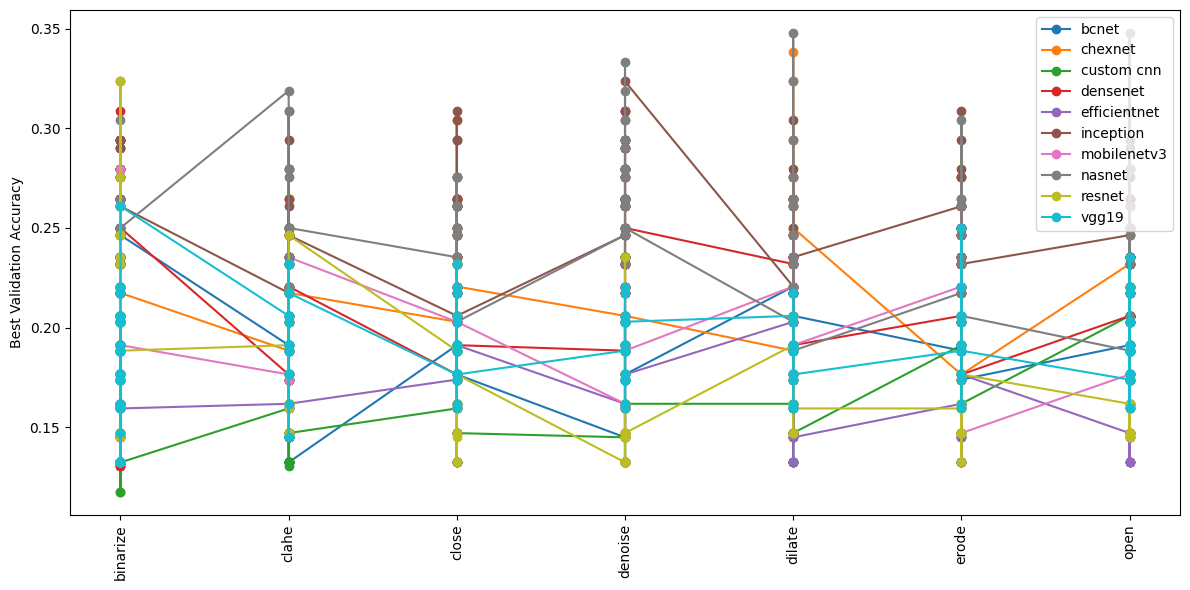

In [10]:
all_results = []
for preproc_id in os.listdir(RESULTS_DIR):
    preproc_path = os.path.join(RESULTS_DIR, preproc_id)
    for model_name in os.listdir(preproc_path):
        model_path = os.path.join(preproc_path, model_name)
        for file in os.listdir(model_path):
            if file.endswith('.csv'):
                df = pd.read_csv(os.path.join(model_path, file))
                df['preproc_id'] = preproc_id
                df['model_name'] = model_name
                df['param_combo'] = file.replace('history_', '').replace('.csv', '')
                all_results.append(df)

results_df = pd.concat(all_results, ignore_index=True)
print(results_df.head())

# Example: plot best_val_acc for each model/preprocessing
plt.figure(figsize=(12,6))
for model in results_df['model_name'].unique():
    subset = results_df[results_df['model_name'] == model]
    plt.plot(subset['preproc_id'], subset['best_val_acc'], 'o-', label=model)
plt.xticks(rotation=90)
plt.ylabel('Best Validation Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

In [13]:
top_k = 10
top_results = results_df.sort_values('best_val_acc', ascending=False).head(top_k)
print(top_results[['preproc_id', 'model_name', 'param_combo', 'best_val_acc', 'best_epoch']])

     preproc_id model_name                                       param_combo  \
1861     dilate     nasnet                    kernel_size-(9_9)_iterations-1   
2347       open     nasnet                    kernel_size-(3_3)_iterations-1   
1697     dilate    chexnet                    kernel_size-(3_3)_iterations-1   
1567    denoise     nasnet                       kernel_size-(15_15)_sigma-2   
1856     dilate     nasnet                    kernel_size-(7_7)_iterations-1   
435    binarize  inception           threshold-100_max_value-50_method-fixed   
1852     dilate     nasnet                    kernel_size-(5_5)_iterations-1   
1497    denoise  inception                         kernel_size-(5_5)_sigma-5   
608    binarize     resnet  threshold-127_max_value-255_method-adaptive_mean   
921       clahe     nasnet                 tile_grid_size-(5_5)_iterations-7   

      best_val_acc  best_epoch  
1861      0.347826          15  
2347      0.347826           9  
1697      0.338235  

In [14]:
# Group by model_name and show mean/max accuracy
model_summary = results_df.groupby('model_name')['best_val_acc'].agg(['mean', 'max', 'std']).sort_values('max', ascending=False)
print(model_summary)

# Group by preprocessing method
preproc_summary = results_df.groupby('preproc_id')['best_val_acc'].agg(['mean', 'max', 'std']).sort_values('max', ascending=False)
print(preproc_summary)

                  mean       max       std
model_name                                
nasnet        0.233993  0.347826  0.034936
chexnet       0.209062  0.338235  0.031545
inception     0.250292  0.323529  0.029919
resnet        0.178380  0.323529  0.030432
densenet      0.219252  0.308824  0.028566
mobilenetv3   0.187493  0.279412  0.026630
bcnet         0.175900  0.264706  0.032486
efficientnet  0.168174  0.260870  0.026490
vgg19         0.189279  0.260870  0.019514
custom cnn    0.156571  0.235294  0.020275
                mean       max       std
preproc_id                              
dilate      0.199043  0.347826  0.038983
open        0.197461  0.347826  0.037323
denoise     0.197338  0.333333  0.047411
binarize    0.194849  0.323529  0.040761
clahe       0.194505  0.318841  0.039193
close       0.201066  0.308824  0.036793
erode       0.197142  0.308824  0.035422


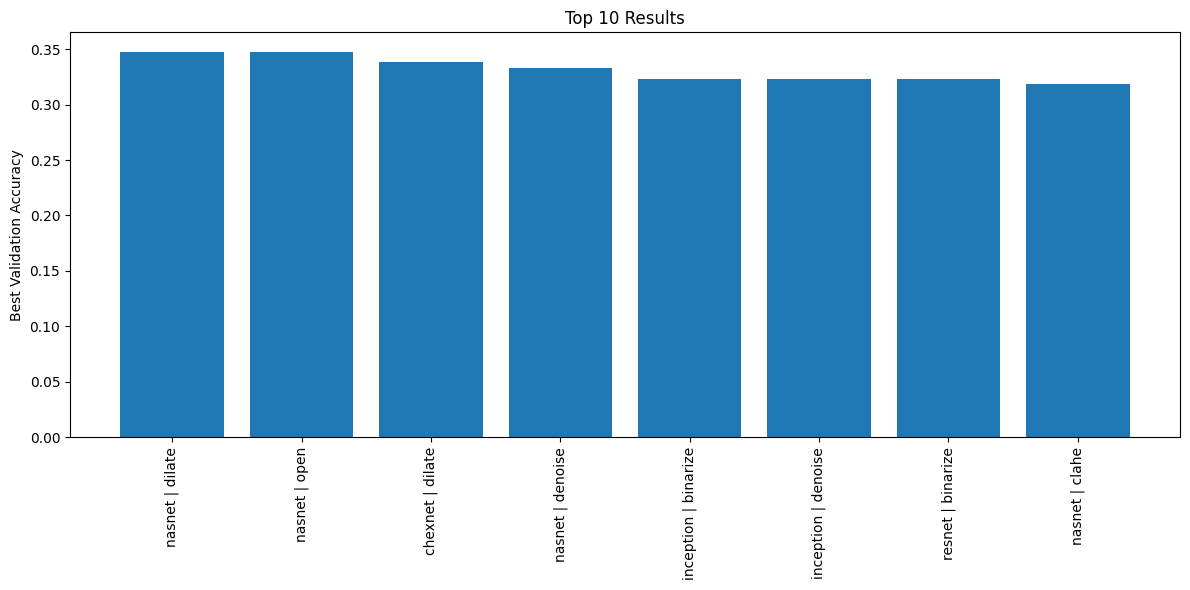

In [15]:
plt.figure(figsize=(12,6))
plt.bar(top_results['model_name'] + ' | ' + top_results['preproc_id'], top_results['best_val_acc'])
plt.xticks(rotation=90)
plt.ylabel('Best Validation Accuracy')
plt.title(f'Top {top_k} Results')
plt.tight_layout()
plt.show()

Top-K Best Validation Accuracies:
     preproc_id model_name                                       param_combo  \
1861     dilate     nasnet                    kernel_size-(9_9)_iterations-1   
2347       open     nasnet                    kernel_size-(3_3)_iterations-1   
1697     dilate    chexnet                    kernel_size-(3_3)_iterations-1   
1567    denoise     nasnet                       kernel_size-(15_15)_sigma-2   
1856     dilate     nasnet                    kernel_size-(7_7)_iterations-1   
435    binarize  inception           threshold-100_max_value-50_method-fixed   
1852     dilate     nasnet                    kernel_size-(5_5)_iterations-1   
1497    denoise  inception                         kernel_size-(5_5)_sigma-5   
608    binarize     resnet  threshold-127_max_value-255_method-adaptive_mean   
921       clahe     nasnet                 tile_grid_size-(5_5)_iterations-7   

      best_val_acc  best_epoch  
1861      0.347826          15  
2347      0.347826 